# no-show-predictor - Analysis
**Author:** Kokouvi Ferdinand DJATA (Ferdio AI Vision)

**Question:** can the no-show of a medical appointment be predicted from information available when the appointment is scheduled, and how much better is a model than simple references?

**Data:** Kaggle *Medical Appointment No Shows* (Brazil, 2016). One row per appointment.

**Method in short**
- Split **by patient** (a patient never appears in both train and test).
- Hyper-parameters tuned with patient-grouped 5-fold CV on the training set; models compared on **CV ROC-AUC**, not on the test set.
- No class weighting (it distorts probabilities); the decision threshold is chosen afterwards on **out-of-fold** predictions of the training set.
- Every model is compared with references that use no model.

In [1]:
import sys, json
from pathlib import Path
sys.path.append('../src')
import numpy as np
import pandas as pd
import joblib
import matplotlib.pyplot as plt
from scipy.stats import chi2_contingency
from sklearn.metrics import roc_curve, precision_recall_curve, roc_auc_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

from train import load_data, make_split
from preprocessing import get_feature_lists, TARGET
from evaluation import calibration_table, metrics_at_threshold

FIG = Path('../figures'); FIG.mkdir(exist_ok=True)
DATA = Path('../data')
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({'font.size': 11, 'figure.dpi': 110})

## 1. Data and cleaning

Rules (see `src/preprocessing.py`):
- Rows with age below 0 or above 110 are removed.
- `Delay_days` is the number of **calendar days** between the scheduling date and the appointment date. The file stores the appointment date at 00:00 and the scheduling as a full timestamp, so a difference in fractional days makes every same-day appointment look negative.
- Rows whose appointment is before the scheduling date are impossible and are removed.
- `Same_day` = (`Delay_days` == 0). Same-day appointments have a very low no-show rate and this jump cannot be represented by a linear model from `Delay_days` alone.
- The patient id is used only to build the grouped split, never as a feature.

In [2]:
df = load_data()
print(df.attrs['cleaning'])
print(f"\nNo-show rate: {100 * df[TARGET].mean():.2f}%")
print(f"Appointments per patient: mean {len(df) / df['patient_id'].nunique():.2f}, "
      f"{100 * (df['patient_id'].value_counts() > 1).mean():.1f}% of patients have more than one appointment")
df[['Age', 'Delay_days', 'Hour_scheduled']].describe().round(2)

{'raw_rows': 110527, 'invalid_age_removed': 6, 'appointment_before_scheduling_removed': 5, 'clean_rows': 110516, 'no_show_rate': 0.20188027073003004, 'unique_patients': 62296, 'neighbourhoods': 81}

No-show rate: 20.19%
Appointments per patient: mean 1.77, 39.1% of patients have more than one appointment


,Age,Delay_days,Hour_scheduled
count,110516.00,110516.00,110516.00
mean,37.09,10.18,10.77
std,23.10,15.26,3.22
min,0.00,0.00,6.00
25%,18.00,0.00,8.00
50%,37.00,4.00,10.00
75%,55.00,15.00,13.00
max,102.00,179.00,21.00


## 2. Exploratory analysis

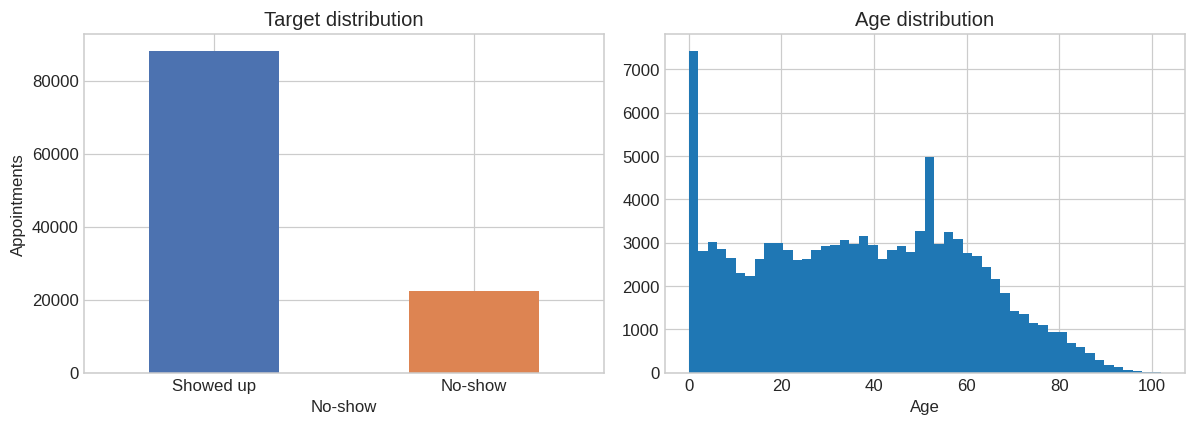

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
df[TARGET].map({0: 'Showed up', 1: 'No-show'}).value_counts().plot(kind='bar', ax=axes[0], color=['#4C72B0', '#DD8452'], rot=0)
axes[0].set_title('Target distribution'); axes[0].set_ylabel('Appointments')
axes[1].hist(df['Age'], bins=50, color='#1f77b4'); axes[1].set_title('Age distribution'); axes[1].set_xlabel('Age')
plt.tight_layout(); plt.savefig(FIG / '01_target_and_age.png', dpi=200); plt.show()

        mean   size
Age                
0-18   21.99  28865
19-30  24.70  16763
31-45  21.37  21953
46-60  17.82  23179
61+    15.20  19756
                      mean   size
Weekday_appointment              
Monday               20.64  22711
Tuesday              20.09  25638
Wednesday            19.69  25866
Thursday             19.34  17244
Friday               21.23  19018
Saturday             23.08     39


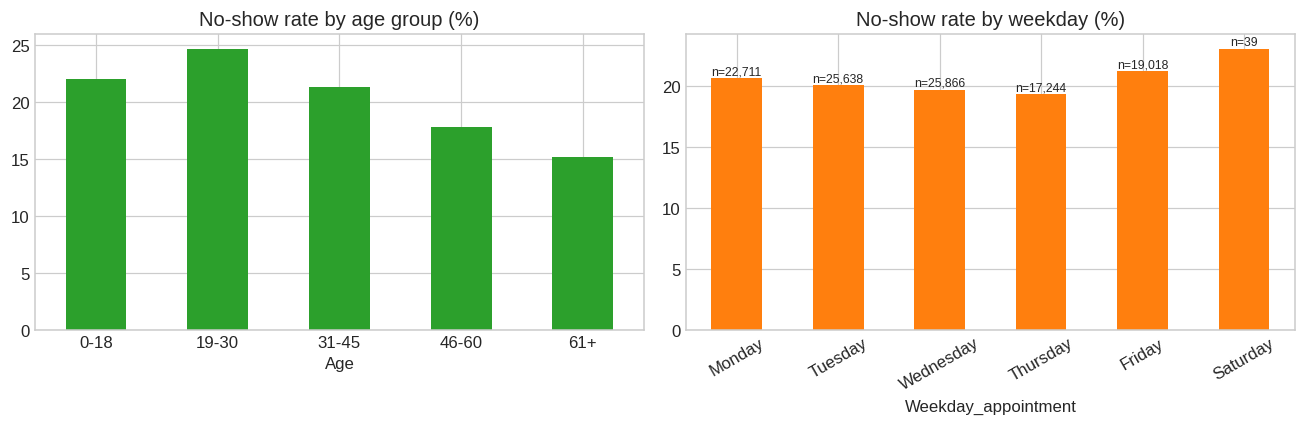

In [4]:
age_bin = pd.cut(df['Age'], bins=[-1, 18, 30, 45, 60, 110], labels=['0-18', '19-30', '31-45', '46-60', '61+'])
age_rate = df.groupby(age_bin, observed=True)[TARGET].agg(['mean', 'size'])
age_rate['mean'] = (100 * age_rate['mean']).round(2)
print(age_rate)
wd = df.groupby('Weekday_appointment')[TARGET].agg(['mean', 'size']).reindex(['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday'])
wd['mean'] = (100 * wd['mean']).round(2)
print(wd)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
age_rate['mean'].plot(kind='bar', ax=axes[0], color='#2ca02c', rot=0); axes[0].set_title('No-show rate by age group (%)')
wd['mean'].plot(kind='bar', ax=axes[1], color='#ff7f0e', rot=30); axes[1].set_title('No-show rate by weekday (%)')
for i, n in enumerate(wd['size']): axes[1].text(i, wd['mean'].iloc[i] + 0.3, f'n={n:,}', ha='center', fontsize=8)
plt.tight_layout(); plt.savefig(FIG / '02_noshow_by_age_and_weekday.png', dpi=200); plt.show()

SMS received (0/1): {0: 16.69, 1: 27.58}
Scholarship (0/1): {0: 19.8, 1: 23.74}
Neighbourhood
SANTA MARTHA         15.84
JARDIM DA PENHA      16.28
TABUAZEIRO           18.27
JARDIM CAMBURI       18.98
BONFIM               19.83
RESISTÊNCIA          20.43
MARIA ORTIZ          21.00
CENTRO               21.09
JESUS DE NAZARETH    24.40
ITARARÉ              26.27
Name: No-show, dtype: float64


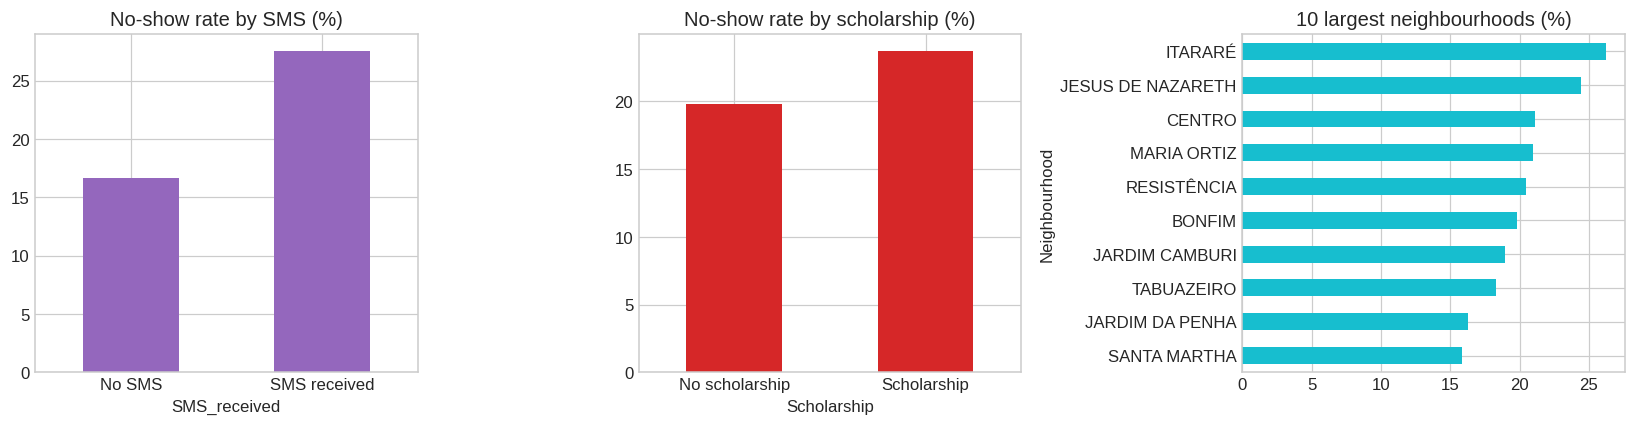

In [5]:
sms = df.groupby('SMS_received')[TARGET].mean() * 100
sch = df.groupby('Scholarship')[TARGET].mean() * 100
print('SMS received (0/1):', sms.round(2).to_dict()); print('Scholarship (0/1):', sch.round(2).to_dict())
top_n = df['Neighbourhood'].value_counts().head(10).index
neigh = (df[df['Neighbourhood'].isin(top_n)].groupby('Neighbourhood')[TARGET].mean() * 100).sort_values()
print(neigh.round(2))
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
sms.plot(kind='bar', ax=axes[0], color='#9467bd', rot=0); axes[0].set_xticklabels(['No SMS', 'SMS received']); axes[0].set_title('No-show rate by SMS (%)')
sch.plot(kind='bar', ax=axes[1], color='#d62728', rot=0); axes[1].set_xticklabels(['No scholarship', 'Scholarship']); axes[1].set_title('No-show rate by scholarship (%)')
neigh.plot(kind='barh', ax=axes[2], color='#17becf'); axes[2].set_title('10 largest neighbourhoods (%)')
plt.tight_layout(); plt.savefig(FIG / '03_noshow_by_sms_scholarship_neighbourhood.png', dpi=200); plt.show()

               mean   size
Delay_days                
0 (same day)   4.65  38561
1             21.35   5213
2-7           24.68  26970
8-15          30.80  13527
16-30         32.51  15868
30+           33.00  10377


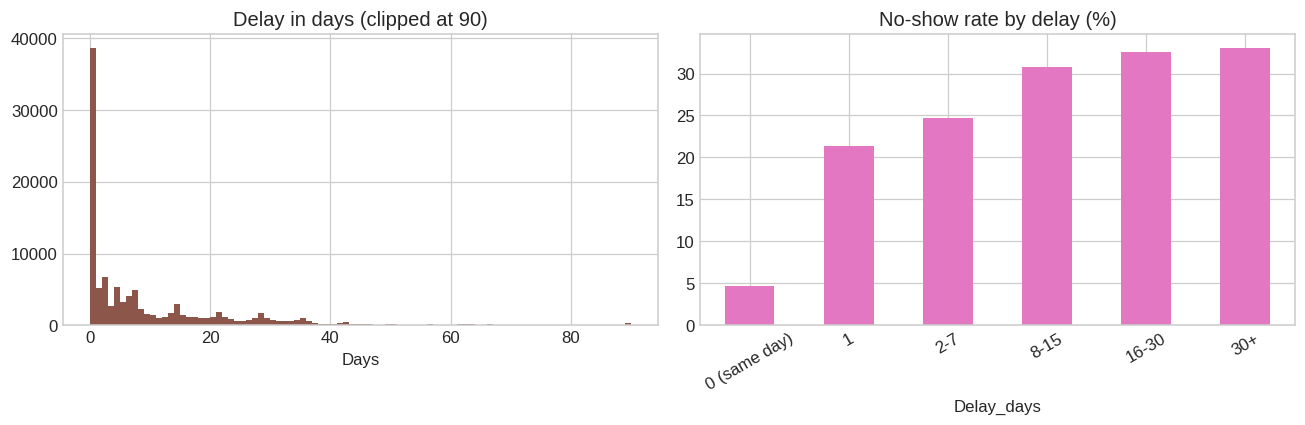

In [6]:
delay_bin = pd.cut(df['Delay_days'], bins=[-1, 0, 1, 7, 15, 30, 400], labels=['0 (same day)', '1', '2-7', '8-15', '16-30', '30+'])
delay_rate = df.groupby(delay_bin, observed=True)[TARGET].agg(['mean', 'size'])
delay_rate['mean'] = (100 * delay_rate['mean']).round(2)
print(delay_rate)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(df['Delay_days'].clip(upper=90), bins=90, color='#8c564b'); axes[0].set_title('Delay in days (clipped at 90)'); axes[0].set_xlabel('Days')
delay_rate['mean'].plot(kind='bar', ax=axes[1], color='#e377c2', rot=30); axes[1].set_title('No-show rate by delay (%)')
plt.tight_layout(); plt.savefig(FIG / '04_delay.png', dpi=200); plt.show()

### The SMS "paradox" is a lead-time effect
Patients who received an SMS have a *higher* crude no-show rate (27.6 % vs 16.7 %). But SMS reminders are only sent for appointments booked a few days ahead, and short lead times have very low no-show rates. Comparing patients **with the same delay** removes this effect.

In [7]:
bins = pd.cut(df['Delay_days'], bins=[-1, 0, 2, 7, 15, 30, 400], labels=['0', '1-2', '3-7', '8-15', '16-30', '30+'])
by_delay = df.groupby(bins, observed=True).agg(appointments=(TARGET, 'size'), sms_rate_pct=('SMS_received', lambda s: 100 * s.mean()))
strat = df.groupby([bins, 'SMS_received'], observed=True)[TARGET].mean().unstack() * 100
strat.columns = ['no_show_pct_without_SMS', 'no_show_pct_with_SMS']
print(by_delay.join(strat).round(1).to_string())

            appointments  sms_rate_pct  no_show_pct_without_SMS  no_show_pct_with_SMS
Delay_days                                                                           
0                  38561           0.0                      4.6                   NaN
1-2                11938           0.0                     22.7                   NaN
3-7                20245          57.0                     26.6                  23.8
8-15               13527          58.6                     34.1                  28.5
16-30              15868          60.5                     36.8                  29.7
30+                10377          61.8                     37.5                  30.2


### Association tests
With 110 000 rows almost any difference is statistically significant, so the p-value alone says little. **Cramer's V** measures the strength of the association (0 = none, 1 = perfect).

In [8]:
rows = []
for var in ['SMS_received', 'Hipertension', 'Scholarship', 'Diabetes', 'Weekday_appointment', 'Handicap_bin', 'Gender', 'Alcoholism', 'Same_day']:
    table = pd.crosstab(df[var], df[TARGET])
    chi2, p, dof, _ = chi2_contingency(table)
    v = np.sqrt(chi2 / (table.values.sum() * (min(table.shape) - 1)))
    rows.append({'Variable': var, 'Chi2': chi2, 'p_value': p, 'dof': dof, 'cramers_v': v, 'significant_05': p < 0.05})
chi2_df = pd.DataFrame(rows).sort_values('cramers_v', ascending=False)
chi2_df.to_csv(DATA / 'chi2_results.csv', index=False)
chi2_df.round(4)

,Variable,Chi2,p_value,dof,cramers_v,significant_05
8,Same_day,8876.2047,0.0000,1,0.2834,True
0,SMS_received,1769.2955,0.0000,1,0.1265,True
1,Hipertension,140.0881,0.0000,1,0.0356,True
2,Scholarship,93.8731,0.0000,1,0.0291,True
4,Weekday_appointment,27.7557,0.0000,5,0.0158,True
3,Diabetes,25.2066,0.0000,1,0.0151,True
5,Handicap_bin,6.7226,0.0095,1,0.0078,True
6,Gender,1.8357,0.1755,1,0.0041,False
7,Alcoholism,0.0013,0.9715,1,0.0001,False


## 3. Models

Trained by `python src/train.py` (patient-grouped split, grouped 5-fold CV on the training set, `ROC-AUC` scoring). Two references need no model: ranking appointments by `Delay_days` alone, and a random ranking (PR-AUC equals the prevalence).

In [9]:
comparison = pd.read_csv(DATA / 'model_comparison.csv')
meta = json.load(open('../models/metadata.json'))
print('Split:', meta['split'])
comparison.round(4)

Split: {'train_rows': 88412, 'test_rows': 22104, 'shared_patients': 0, 'no_show_rate_train': 0.20188435958919604, 'no_show_rate_test': 0.20186391603329715}


,Model,best_params,cv_roc_auc,cv_roc_auc_std,test_roc_auc,test_pr_auc,test_brier
0,LogisticRegression,{'clf__C': 0.01},0.7213,0.0036,0.7196,0.3478,0.1453
1,DecisionTree,"{'clf__max_depth': 7, 'clf__min_samples_leaf':...",0.7256,0.0038,0.7228,0.3436,0.1450
2,KNN,{'clf__n_neighbors': 201},0.7221,0.0025,0.7250,0.3510,0.1447
3,Delay_days alone (no model),NaN,NaN,NaN,0.6943,0.3035,NaN
4,Random ranking (prevalence),NaN,NaN,NaN,0.5000,0.2019,NaN


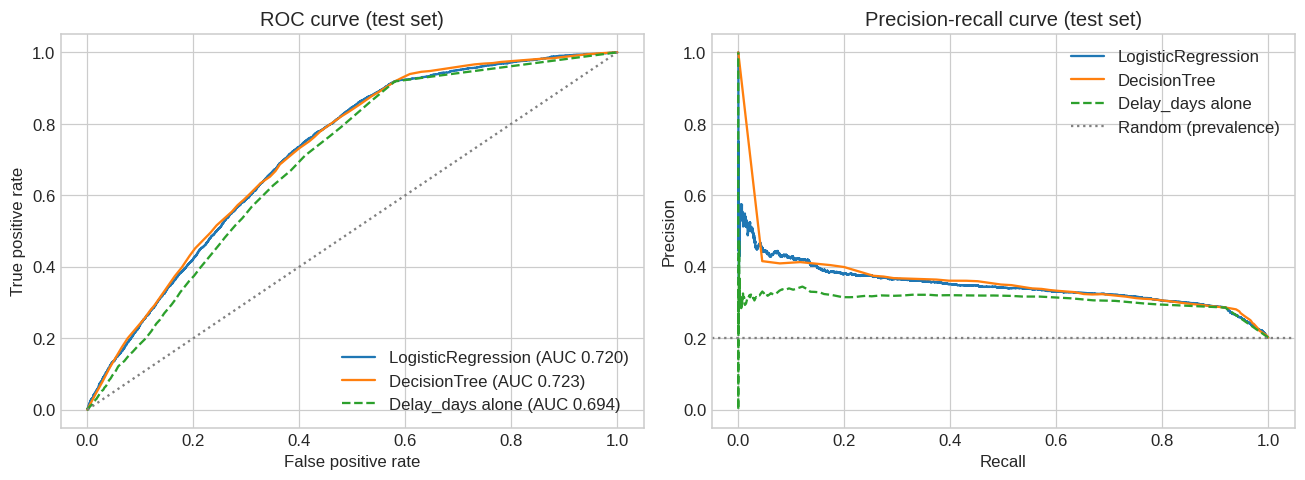

In [10]:
train_idx, test_idx = make_split(df)
cat_cols, num_cols = get_feature_lists()
X_test, y_test = df.iloc[test_idx][cat_cols + num_cols], df.iloc[test_idx][TARGET]
X_train, y_train = df.iloc[train_idx][cat_cols + num_cols], df.iloc[train_idx][TARGET]
lr = joblib.load('../models/model_LogisticRegression.joblib')
dt = joblib.load('../models/model_DecisionTree.joblib')
p_lr, p_dt = lr.predict_proba(X_test)[:, 1], dt.predict_proba(X_test)[:, 1]
delay = X_test['Delay_days'].to_numpy()

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
for label, score, style in [('LogisticRegression', p_lr, '-'), ('DecisionTree', p_dt, '-'), ('Delay_days alone', delay, '--')]:
    fpr, tpr, _ = roc_curve(y_test, score); axes[0].plot(fpr, tpr, style, label=f'{label} (AUC {roc_auc_score(y_test, score):.3f})')
    pr, rc, _ = precision_recall_curve(y_test, score); axes[1].plot(rc, pr, style, label=label)
axes[0].plot([0, 1], [0, 1], ':', color='grey'); axes[0].set_xlabel('False positive rate'); axes[0].set_ylabel('True positive rate'); axes[0].set_title('ROC curve (test set)'); axes[0].legend()
axes[1].axhline(y_test.mean(), ls=':', color='grey', label='Random (prevalence)'); axes[1].set_xlabel('Recall'); axes[1].set_ylabel('Precision'); axes[1].set_title('Precision-recall curve (test set)'); axes[1].legend()
plt.tight_layout(); plt.savefig(FIG / 'roc_pr_curves.png', dpi=200); plt.show()

### How much do the other features add to the delay?
A small tree that only sees the delay and the age, compared with the full model.

In [11]:
def small_tree(cols, depth, leaf=300):
    m = DecisionTreeClassifier(max_depth=depth, min_samples_leaf=leaf, random_state=42).fit(X_train[cols], y_train)
    return roc_auc_score(y_test, m.predict_proba(X_test[cols])[:, 1])
print(f"Delay_days + Same_day only : test ROC-AUC {small_tree(['Delay_days', 'Same_day'], 4):.4f}")
print(f"+ Age                      : test ROC-AUC {small_tree(['Delay_days', 'Same_day', 'Age'], 5):.4f}")
print(f"Full deployed decision tree: test ROC-AUC {roc_auc_score(y_test, p_dt):.4f}")

Delay_days + Same_day only : test ROC-AUC 0.6948
+ Age                      : test ROC-AUC 0.7189
Full deployed decision tree: test ROC-AUC 0.7228


### Calibration
A model is calibrated when a predicted 30 % corresponds to about 30 % observed no-shows. Class weighting would break this (average prediction about 0.44 for a 20 % base rate), which is why it is not used here.

   mean_predicted  observed_rate     n
0           0.024          0.033  2239
1           0.035          0.028  2322
2           0.050          0.047  2203
3           0.150          0.166  2450
4           0.205          0.212  1926
5           0.239          0.243  2366
6           0.272          0.265  1995
7           0.312          0.326  3050
8           0.350          0.325  1632
9           0.423          0.404  1921

Mean predicted probability 0.201 vs observed rate 0.202


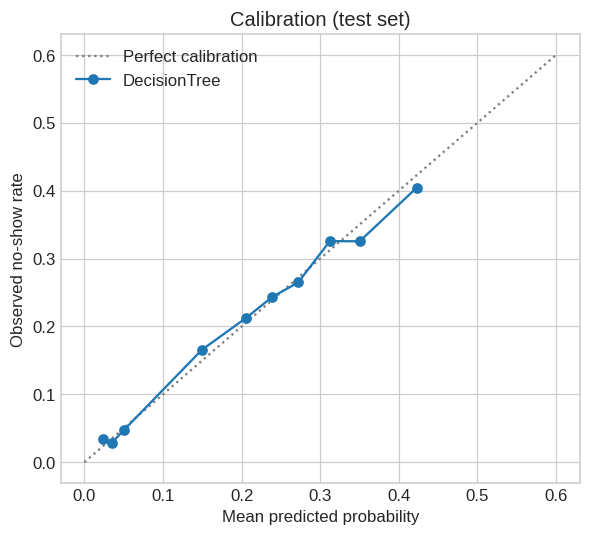

In [12]:
cal = calibration_table(y_test, p_dt, n_bins=10)
print(cal.round(3))
print(f"\nMean predicted probability {p_dt.mean():.3f} vs observed rate {y_test.mean():.3f}")
plt.figure(figsize=(5.5, 5))
plt.plot([0, 0.6], [0, 0.6], ':', color='grey', label='Perfect calibration')
plt.plot(cal['mean_predicted'], cal['observed_rate'], 'o-', label='DecisionTree')
plt.xlabel('Mean predicted probability'); plt.ylabel('Observed no-show rate'); plt.title('Calibration (test set)'); plt.legend()
plt.tight_layout(); plt.savefig(FIG / 'calibration.png', dpi=200); plt.show()

## 4. Decision threshold

The threshold is not tuned on the test set. For each target recall, the threshold is chosen on **out-of-fold** predictions of the training set (in `train.py`), then evaluated once on the test set.

      target_recall_oof  threshold  precision  recall  flagged_rate      tp      fp      fn       tn
0.5                0.50      0.285      0.348   0.516         0.299  2301.0  4302.0  2161.0  13340.0
0.65               0.65      0.254      0.324   0.652         0.407  2909.0  6080.0  1553.0  11562.0
0.8                0.80      0.215      0.309   0.779         0.508  3474.0  7753.0   988.0   9889.0


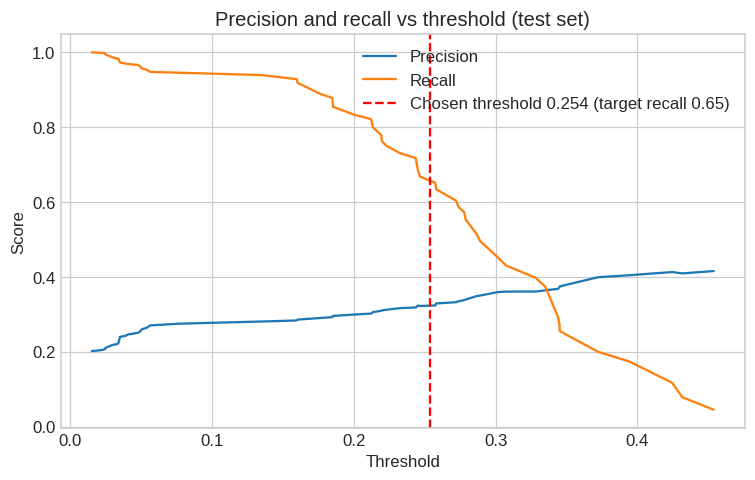

In [13]:
ops = pd.DataFrame(meta['operating_points']).T[['target_recall_oof', 'threshold', 'precision', 'recall', 'flagged_rate', 'tp', 'fp', 'fn', 'tn']]
print(ops.round(3).to_string())
prec, rec, thr = precision_recall_curve(y_test, p_dt)
plt.figure(figsize=(7, 4.5))
plt.plot(thr, prec[:-1], label='Precision'); plt.plot(thr, rec[:-1], label='Recall')
plt.axvline(meta['threshold'], color='red', ls='--', label=f"Chosen threshold {meta['threshold']:.3f} (target recall {meta['target_recall']})")
plt.xlabel('Threshold'); plt.ylabel('Score'); plt.title('Precision and recall vs threshold (test set)'); plt.legend()
plt.tight_layout(); plt.savefig(FIG / 'threshold_tradeoff.png', dpi=200); plt.show()

## 5. Which features matter?

Delay_days             0.2043
Age                    0.0313
SMS_received           0.0058
Hour_scheduled         0.0026
Gender                 0.0006
Hipertension           0.0002
Diabetes               0.0001
Neighbourhood          0.0000
Alcoholism             0.0000
Scholarship            0.0000
Handicap_bin           0.0000
Same_day               0.0000
Weekday_appointment   -0.0005


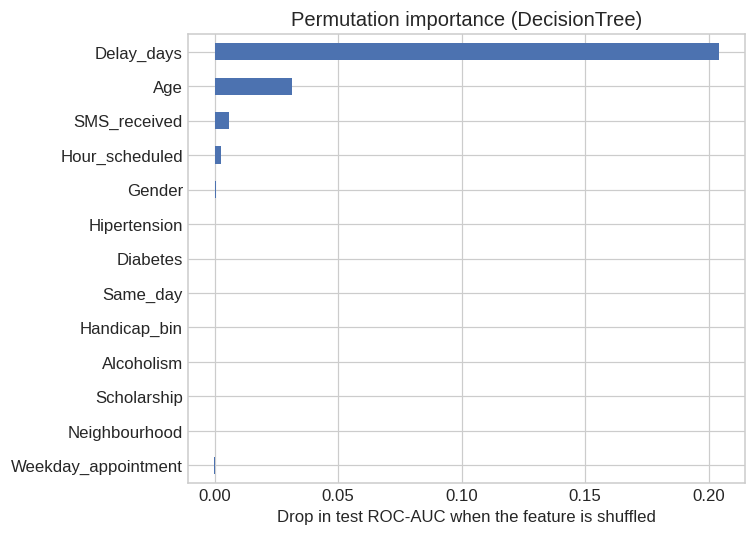

In [14]:
imp = pd.Series(meta['permutation_importance_auc_drop']).sort_values()
print(imp.sort_values(ascending=False).round(4).to_string())
plt.figure(figsize=(7, 5)); imp.plot(kind='barh', color='#4C72B0')
plt.xlabel('Drop in test ROC-AUC when the feature is shuffled'); plt.title('Permutation importance (DecisionTree)')
plt.tight_layout(); plt.savefig(FIG / 'feature_importance.png', dpi=200); plt.show()

## 6. Conclusions

- **The three models are equivalent.** Cross-validated ROC-AUC: logistic regression 0.7213, decision tree 0.7256, k-NN 0.7221 (standard deviations about 0.004). On the held-out patients the test ROC-AUC is 0.720, 0.723 and 0.725. The decision tree is deployed because it is interpretable and small, not because it is significantly better.
- **The delay carries most of the signal.** Ranking appointments by `Delay_days` alone gives ROC-AUC 0.694; the full model adds about 0.03. The most influential features (permutation importance) are Delay_days, Age, SMS_received, Hour_scheduled.
- **Useful but modest.** PR-AUC is 0.344 against 0.202 for a random ranking. At the threshold chosen for a recall target of 0.65, the test recall is 65.2 %, 32.4 % of the flagged appointments are real no-shows, and 40.7 % of all appointments are flagged.
- **Probabilities are calibrated to this dataset**: mean prediction 0.201 against an observed rate of 0.202. With class weighting the mean prediction would be about 0.44.

**Limitations.** A single Brazilian dataset from 2016 with unidentified site(s); no temporal validation (the split is by patient, not by date); no history of previous no-shows, distance or provider information; observational data: the higher crude no-show rate among patients who received an SMS is explained by lead time (SMS are never sent for appointments booked 2 days ahead or less), and within each delay group SMS recipients have a lower no-show rate, but this is still an association and not proof of a causal effect; no fairness audit across neighbourhoods or age groups. The model is decision support for targeting reminder calls and must not be used to refuse appointments.